In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [29]:
df = pd.read_csv("dataset.csv")

### **Basic** **Dataset** **Inspection**

In [30]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


### **Remove** **Null** **Values**

In [31]:
df.dropna(inplace=True)

### **Remove** **Duplicate** **Rows**

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.drop_duplicates(inplace=True)

### **Remove** **Unnecessary** **Columns**

In [34]:
df.drop(columns=[
    'Unnamed: 0',
    'track_id',
    'track_name',
    'album_name',
    'artists'
], inplace=True)

### **Convert** **Boolean** **Column**

In [35]:
df['explicit'] = df['explicit'].astype(int)

### **Create** **Target** **Variable**

In [36]:
df['hit'] = np.where(df['popularity'] >= 70, 1, 0)

### **Remove** **Popularity** **Column**

In [37]:
df.drop(columns=['popularity'], inplace=True)

### **Check** **Dataset**

In [38]:
print(df.head())
print(df.shape)

   duration_ms  explicit  danceability  energy  key  loudness  mode  \
0       230666         0         0.676  0.4610    1    -6.746     0   
1       149610         0         0.420  0.1660    1   -17.235     1   
2       210826         0         0.438  0.3590    0    -9.734     1   
3       201933         0         0.266  0.0596    0   -18.515     1   
4       198853         0         0.618  0.4430    2    -9.681     1   

   speechiness  acousticness  instrumentalness  liveness  valence    tempo  \
0       0.1430        0.0322          0.000001    0.3580    0.715   87.917   
1       0.0763        0.9240          0.000006    0.1010    0.267   77.489   
2       0.0557        0.2100          0.000000    0.1170    0.120   76.332   
3       0.0363        0.9050          0.000071    0.1320    0.143  181.740   
4       0.0526        0.4690          0.000000    0.0829    0.167  119.949   

   time_signature track_genre  hit  
0               4    acoustic    1  
1               4    acoustic 

### **Visualize** **Class** **Distribution**

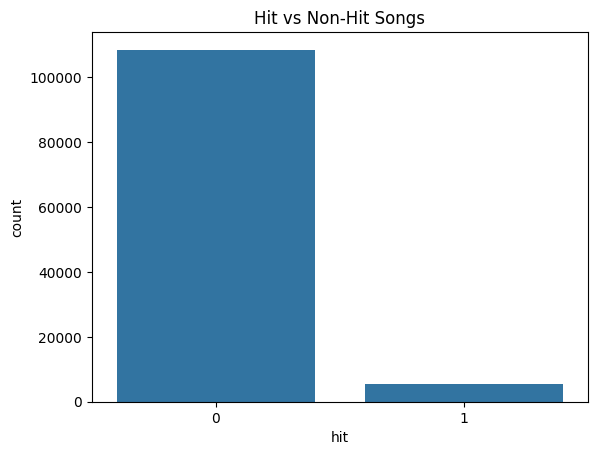

In [40]:
import seaborn as sns
sns.countplot(x=df['hit'])
plt.title("Hit vs Non-Hit Songs")
plt.show()

### **Correlation** **Heatmap**

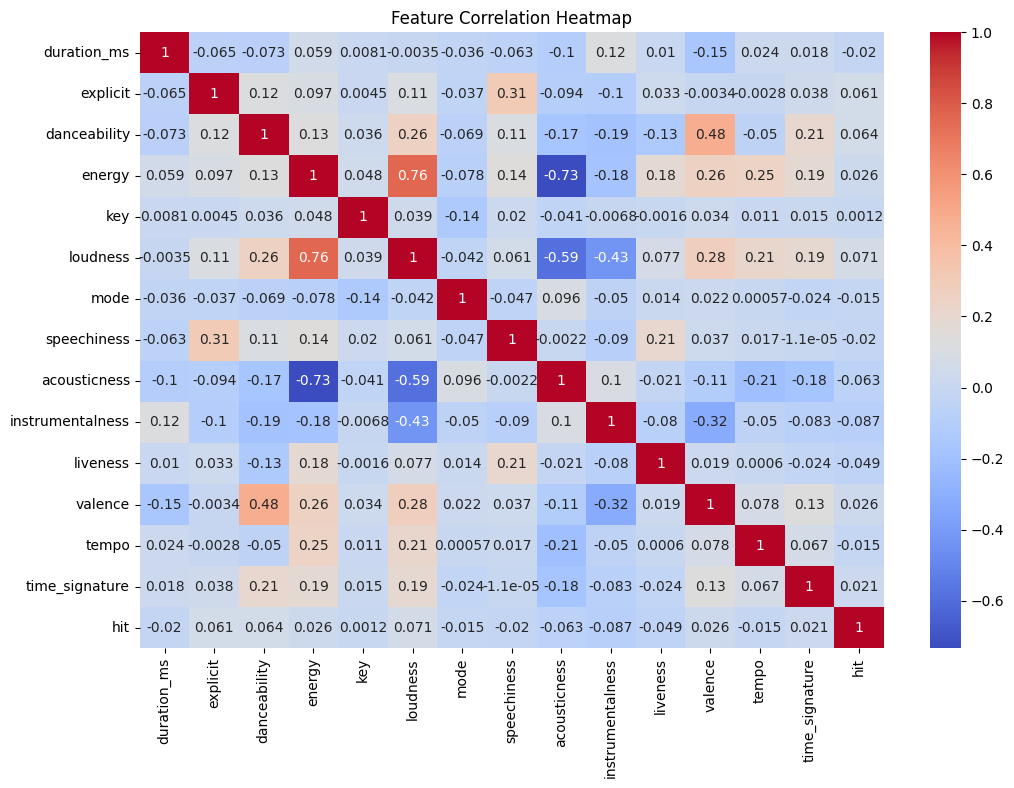

In [41]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

### **Separate** **Features** **and** **Target**

**Features**

In [42]:
X = df.drop(columns=['hit', 'track_genre'])

**Target**

In [43]:
y = df['hit']

### **Feature** **Scaling**

In [44]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### **Train**-**Test** **Split**

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

### **Final** **Shape** **Check**

In [46]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(91199, 14)
(22800, 14)
(91199,)
(22800,)


### **Feature** **Histograms**

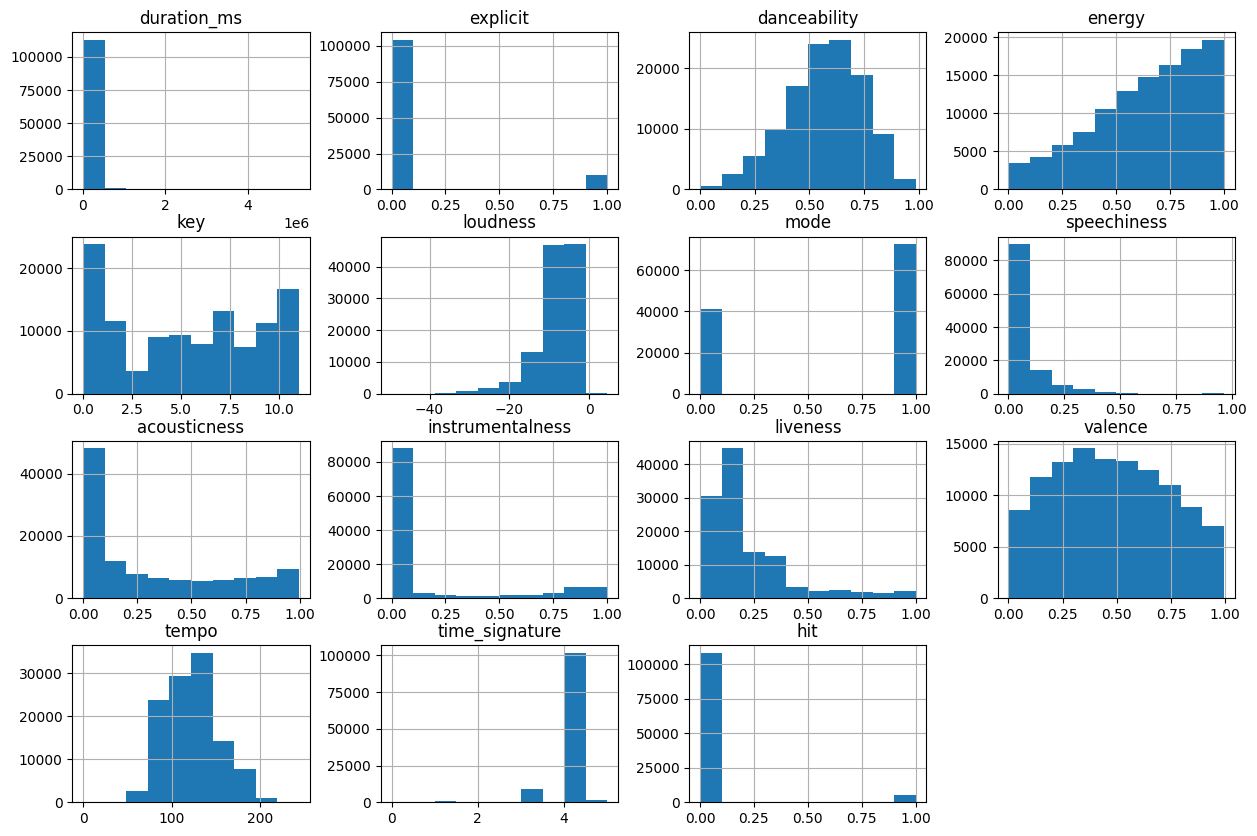

In [47]:
df.hist(figsize=(15,10))
plt.show()